# Improving Domain-Specific Question Answering using Retrieval-Augmented Generation

| Field | Details |
|-------|---------|
| **Course** | Natural Language Processing — Final Project |
| **Group Members** | Nishi Patel (501356244) · Avikumar Patel (501376903) |
| **Paper Github Link** | https://github.com/hyintell/RetrievalQA/tree/main |
| **Paper** | RetrievalQA: Assessing Adaptive RAG for Short-form Open-Domain QA (ACL Findings 2024) |
| **Paper Link** | https://arxiv.org/abs/2402.16457 |
| **Dataset** | hyintell/RetrievalQA (HuggingFace) |

In [ ]:
# ── Install all required libraries ──────────────────────────────────
# datasets          -> loads the RetrievalQA benchmark from HuggingFace
# sentence-transformers -> converts text into dense 384-dim vectors
# faiss-cpu         -> fast cosine similarity search over vectors
# transformers      -> access to free HuggingFace language models
!pip install datasets sentence-transformers faiss-cpu transformers -q
print('All libraries installed successfully!')

All libraries installed successfully!


In [3]:
import sys
sys.path.append('src')

# Project modules
from data_loader   import load_retrievalqa_dataset, explore_dataset, show_examples, create_sample
from retriever     import build_index, retrieve
from llm           import load_model, generate_answer
from strategies    import build_prompt_no_retrieval, build_prompt_always_retrieval, build_prompt_adaptive
from evaluation    import run_experiments, compute_scores, error_analysis
from visualisation import plot_pipeline, plot_results, plot_paper_architecture

# Standard libraries
import pandas as pd
import numpy  as np

print('All imports successful!')

All imports successful!


## 1. Introduction

Large Language Models (LLMs) such as GPT-3.5 often generate confident
but factually incorrect answers when faced with questions about recent
or specialised knowledge — a problem known as **hallucination**. This
occurs because LLMs rely solely on knowledge memorised during training,
which has a fixed cutoff date and cannot be updated at inference time.

This project studies **Retrieval-Augmented Generation (RAG)** as a
solution. RAG improves LLM accuracy by first retrieving relevant
documents from an external database and conditioning the model's answer
on that retrieved evidence — similar to allowing a student to use a
reference book during an exam. We evaluate three retrieval strategies
— No Retrieval, Always Retrieval, and Adaptive Retrieval — on the
publicly available RetrievalQA benchmark (Zhang et al., ACL 2024)
and measure performance using Exact Match and Token F1 metrics.

## 2. Background

### 2.1 The Problem — LLM Hallucination

Large Language Models store all knowledge in billions of numerical
parameters learned during training (**parametric knowledge storage**).
This creates three critical limitations:

1. **Knowledge cutoff** — the model cannot know anything after its training date.
2. **Hallucination** — when uncertain, the model generates a confident but wrong answer.
3. **Long-tail failure** — obscure entities are underrepresented in training data.

### 2.2 Retrieval-Augmented Generation (RAG)

RAG (Lewis et al., 2020) addresses these limitations by augmenting
generation with external knowledge retrieval. The model:
1. **Retrieves** the most relevant documents from an external corpus
2. **Augments** the prompt by prepending retrieved passages as context
3. **Generates** an answer conditioned on both question and evidence

> **Final Answer = LLM ( Question + Retrieved Context )**

### 2.3 Paper Summary — RetrievalQA (Zhang et al., ACL Findings 2024)

The paper asks: *Does an LLM even know when it needs to retrieve?*
The authors built a benchmark of **2,785 short-form QA questions** from
five sources (PopQA, TriviaQA, RealTimeQA, FreshQA, ToolQA) and tested
three strategies: No Retrieval, Always Retrieval, and Adaptive Retrieval
with **TAARE** (Token-Aware Adaptive REtrieval) prompting.

**Key finding:** LLMs failed to trigger adaptive retrieval on >50% of
questions that objectively required it — they are poor judges of their
own knowledge gaps. Always Retrieval significantly outperforms No
Retrieval on knowledge-intensive questions.

## 3. Methodology

We implement the **Always Retrieval** strategy from the RetrievalQA
paper as our primary method. The pipeline has five sequential steps:

| Step | Component | Tool |
|------|-----------|------|
| 1. Encode | Question -> 384-dim vector | SentenceTransformers (all-MiniLM-L6-v2) |
| 2. Search | Vector -> top-3 passages | FAISS IndexFlatIP |
| 3. Augment | Passages + Question -> prompt | Custom prompt builder |
| 4. Generate | Prompt -> answer | google/flan-t5-base |
| 5. Evaluate | Answer vs ground truth | Exact Match + Token F1 |

**Prompt template (Always Retrieval):**
```
Use the following context to answer the question.

Context:
- [Passage 1]
- [Passage 2]
- [Passage 3]

Question: [user question]
Answer:
```

Two comparison strategies are also run to measure the benefit of retrieval:
- **No Retrieval** — LLM answers from memory only
- **Adaptive Retrieval** — oracle version using the `param_knowledge_answerable` label

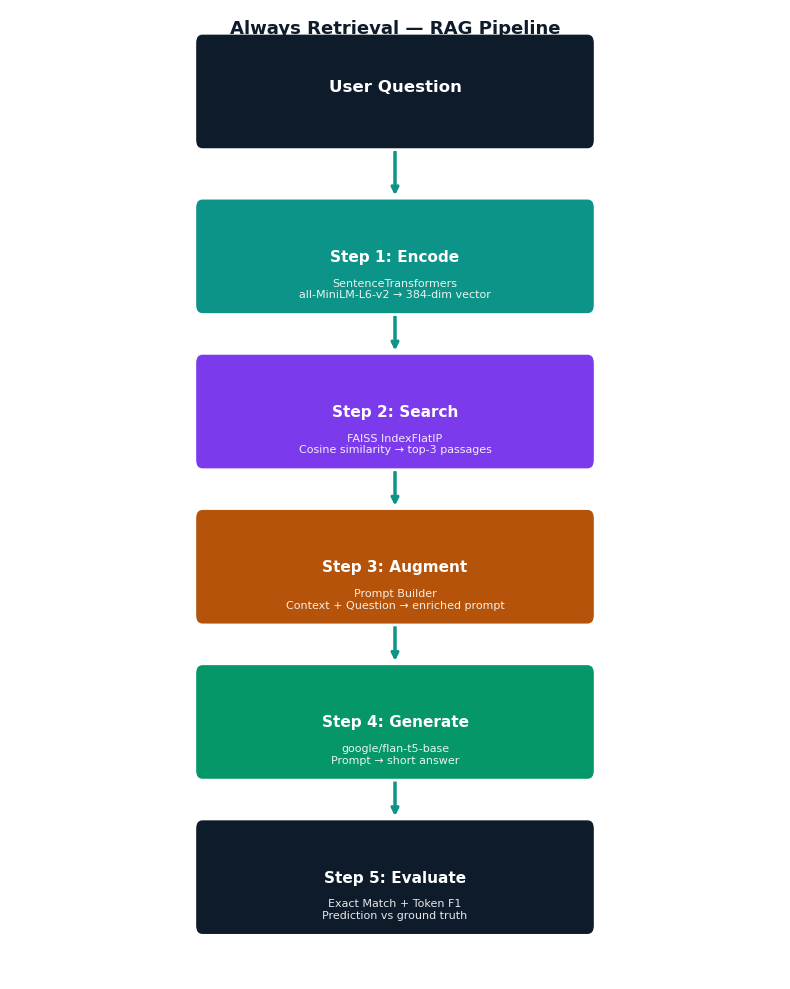

Pipeline diagram saved as rag_pipeline.png


In [5]:
# Full implementation is in src/visualisation.py -> plot_pipeline()
plot_pipeline(save_path='rag_pipeline.png')

## Original Paper Architecture — RetrievalQA (Zhang et al., ACL 2024)

The RetrievalQA paper presents a three-part architecture to evaluate
whether LLMs know when they need to retrieve external information.

---

### Part 1 — Dataset Construction

The authors collected **9,336 raw questions** from five sources and
filtered them using GPT-4 in a closed-book setting. Only questions
where GPT-4 scored Token F1 = 0 (completely unanswerable without
retrieval) were kept. This produced **1,271 retrieval-needed questions**.
An additional **1,514 parametric questions** — answerable by GPT-2 from
memory alone — were added to balance the dataset.

**Final dataset: 2,785 questions** across five sources:

| Source | Count | Type |
|--------|-------|------|
| PopQA | 659 | Long-tail Wikipedia entities |
| TriviaQA | 295 | General trivia and factual |
| RealTimeQA | 188 | Recent news and world events |
| FreshQA | 54 | Fast-changing web knowledge |
| ToolQA | 75 | Personal agenda queries |
| Parametric | 1,514 | Answerable from LLM memory |

---

### Part 2 — ARAG Evaluation Framework

Three retrieval strategies are evaluated across six LLMs
(TinyLlama 1.1B, Phi-2 2.7B, Llama-2 7B, Self-RAG 7B, GPT-3.5, GPT-4):

**Strategy 1 — No Retrieval:** LLM answers from memory only.
`y = LLM(I, x)`

**Strategy 2 — Always Retrieval:** Top-5 documents always retrieved
via Contriever (Wikipedia) or Google Search, then prepended to prompt.
`y = LLM(I, Dx, x)`

**Strategy 3 — Adaptive Retrieval:** LLM decides whether to retrieve.
Two methods tested:
- **Vanilla prompting** — simple yes/no question: *"Do you need
  external information to answer? [Yes]/[No]"*
- **TA-ARE (paper's proposed method)** — adds today's date + 4
  in-context examples (2 Yes + 2 No) to help the LLM reason about
  its own knowledge gaps

---

### Part 3 — Evaluation and Key Findings

**Metrics used:**
- **Match accuracy** — is the gold answer contained in the prediction?
- **Retrieval accuracy** — did the model retrieve when it should have?

**Key findings:**
1. GPT-3.5 with vanilla prompting only triggered retrieval **49.3%**
   of the time on questions that required it — failing more than half
   the time. This is the paper's core finding.
2. TA-ARE improved GPT-3.5 retrieval accuracy by **+37 percentage
   points** (49.3% → 86.3%) and match accuracy by **+15 points**.
3. Always Retrieval consistently outperforms adaptive methods as an
   upper bound, confirming that retrieval always helps on
   knowledge-intensive questions.

The architecture diagram below illustrates all three parts of this
pipeline as described in the original paper.

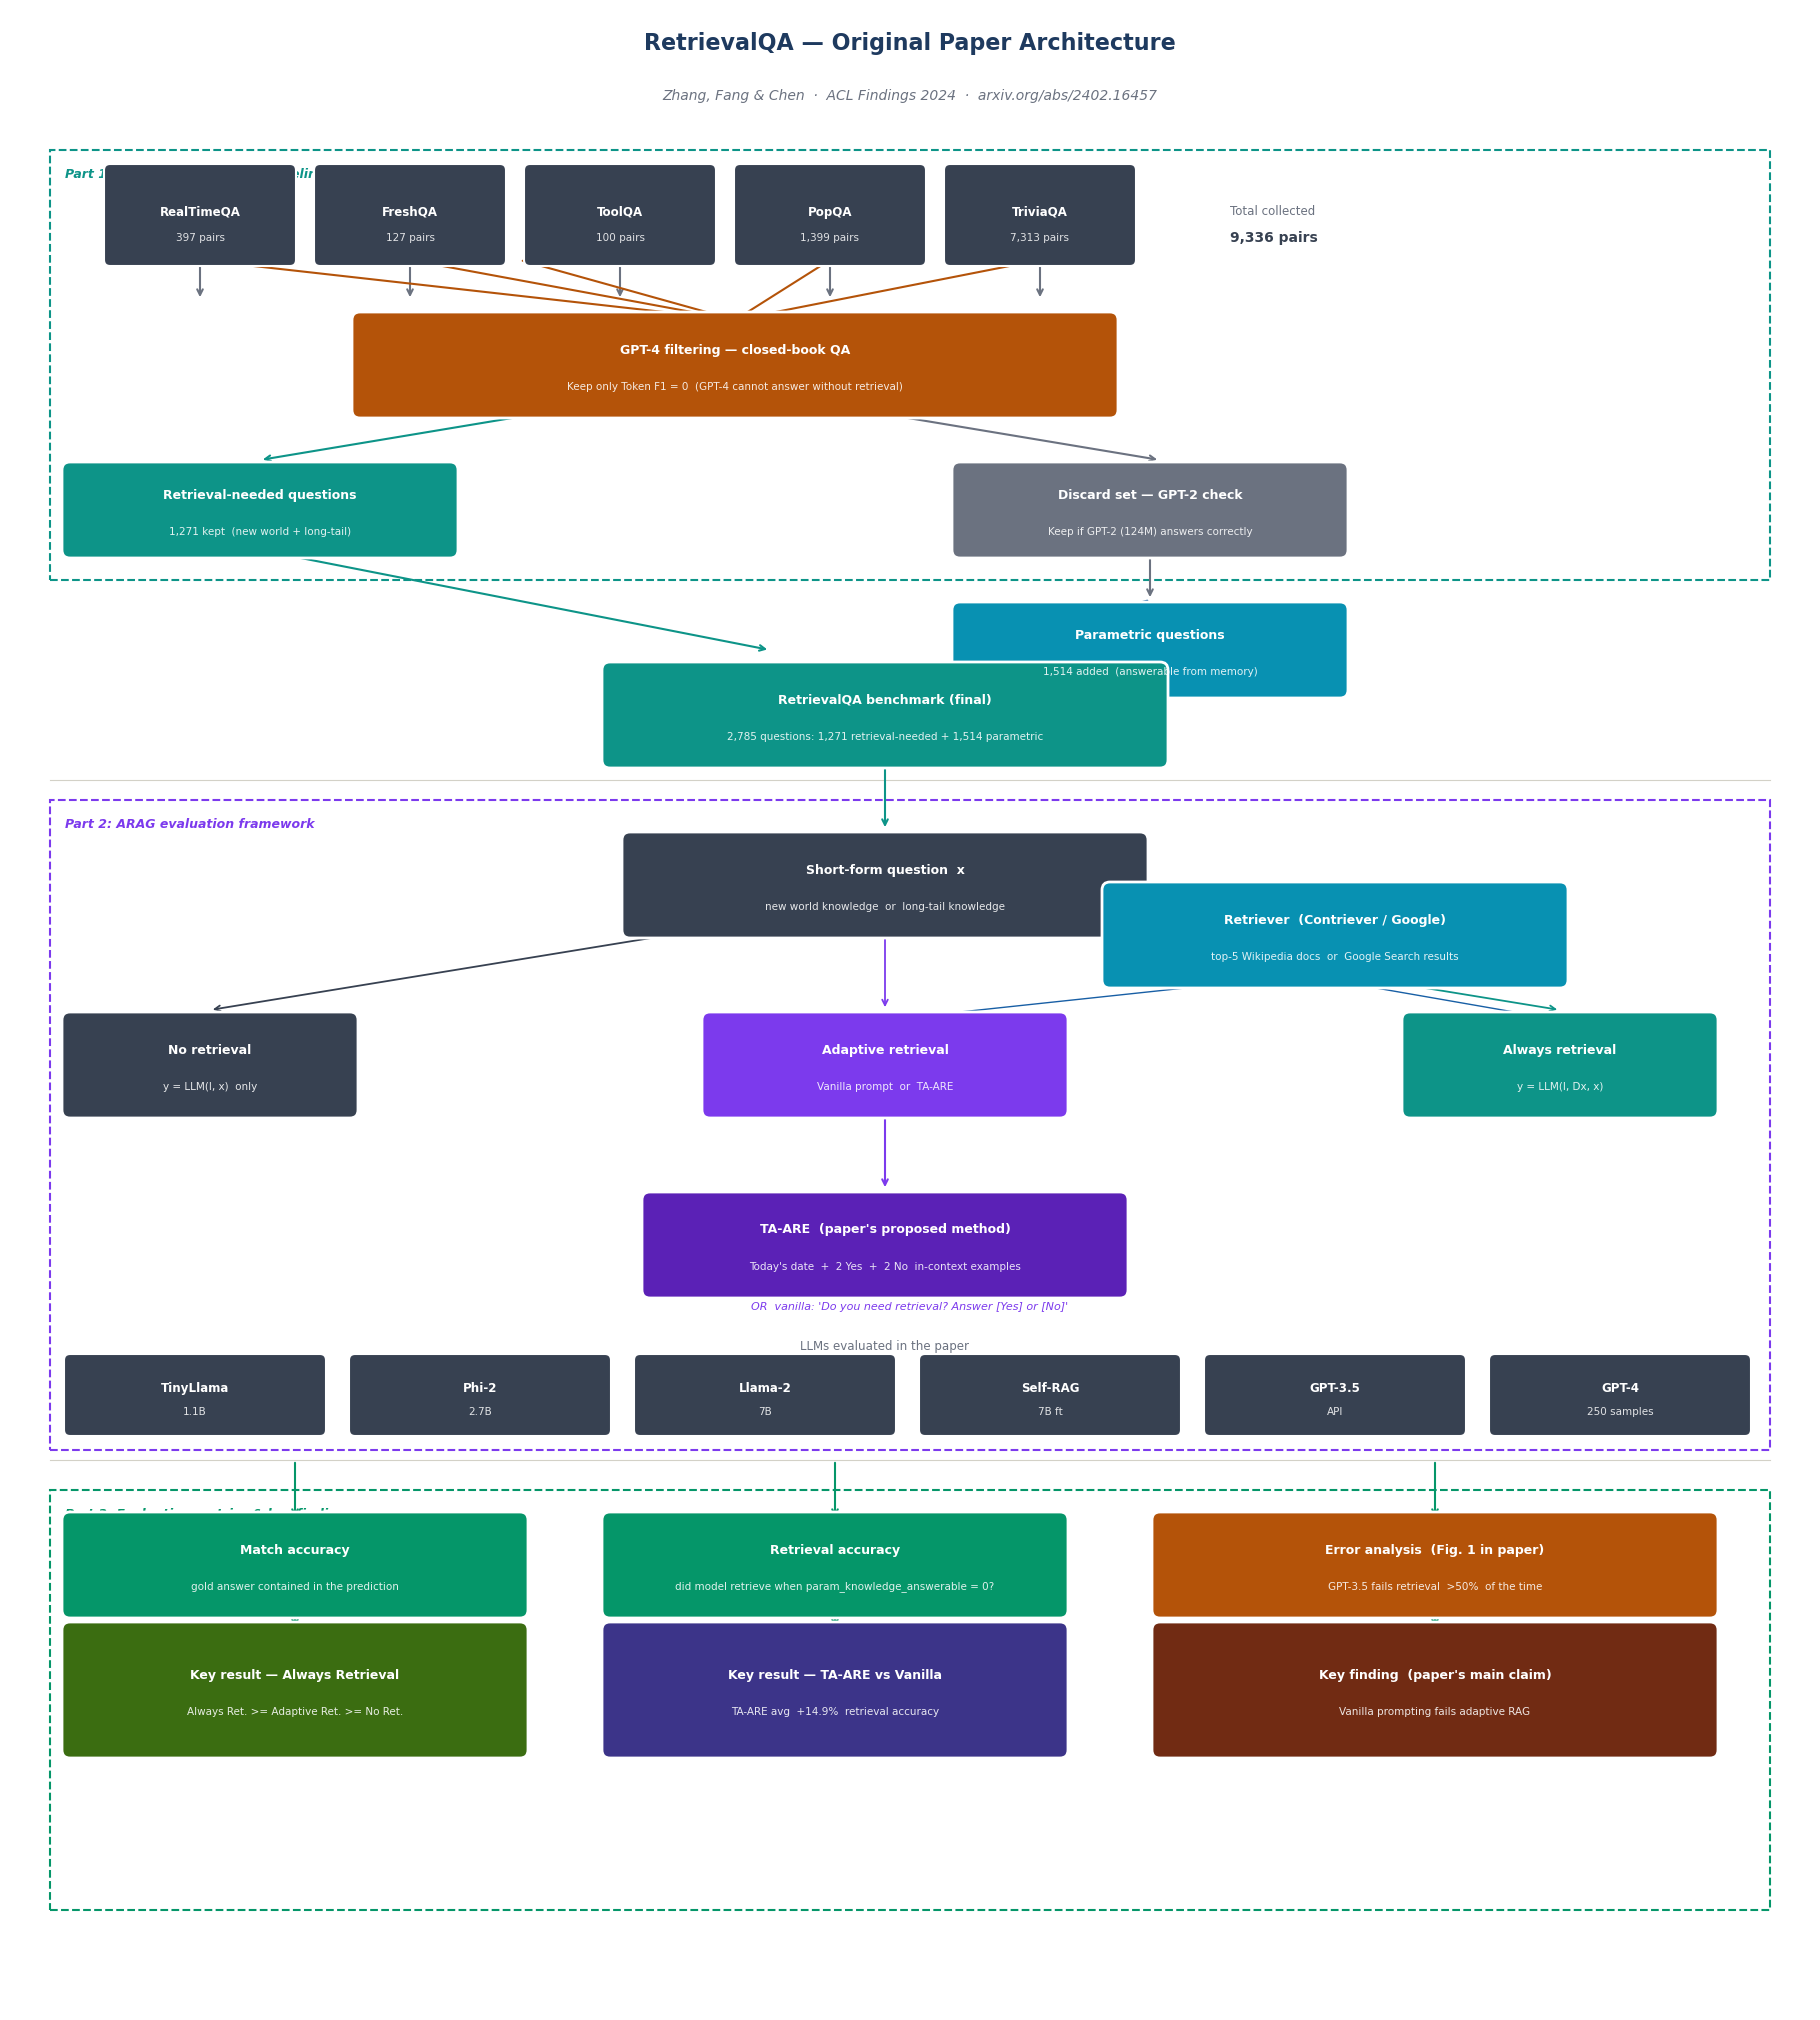

Original paper architecture saved as original_paper_architecture.png


In [6]:
plot_paper_architecture(save_path='original_paper_architecture.png')

## Differences from the Original Paper

This section explicitly documents the differences between what the
original RetrievalQA paper (Zhang et al., ACL 2024) implemented and
what we implemented in this project. These differences exist due to
computational constraints, time limitations, and the educational
scope of this project.

---

### Comparison Table

| Aspect | Original Paper | Our Implementation |
|--------|---------------|-------------------|
| **Language Model** | GPT-3.5-turbo (OpenAI API) | google/flan-t5-base (free, local CPU) |
| **Model Size** | ~175 billion parameters | ~250 million parameters |
| **Adaptive Method** | TAARE prompting — LLM decides | Oracle label (param_knowledge_answerable) |
| **Retrieval System** | BM25 + dense retriever (live) | Pre-retrieved passages from dataset |
| **Questions Evaluated** | Full 2,785 questions | 100-question balanced sample |
| **Evaluation Split** | Multiple LLMs tested | Single LLM (flan-t5-base) |
| **Self-RAG comparison** | Yes — compared with Self-RAG | Not implemented |
| **Infrastructure** | Cloud-based API calls | Local CPU, Google Colab |

---

### Detailed Explanation of Each Difference

#### 1. Language Model — GPT-3.5 vs flan-t5-base

**Original paper:** The authors used GPT-3.5-turbo via the OpenAI API,
a state-of-the-art model with approximately 175 billion parameters.
They also tested other large models including text-davinci-003.

**Our implementation:** We used google/flan-t5-base, a free open-source
model with approximately 250 million parameters — roughly 700 times
smaller than GPT-3.5. We chose it because it requires no API key, runs
entirely on CPU, and has no cost.

**Impact:** This is the biggest reason our absolute scores are lower
than the paper's. Even when the correct answer was clearly present
in the retrieved context, flan-t5-base sometimes failed to extract
it correctly — it would rephrase the answer slightly or include extra
words, causing Exact Match to return 0. A larger model would read the
context more reliably and produce much higher scores.

**Why it does not invalidate our results:** The relative improvement
between strategies is still meaningful. A 14× improvement in Exact
Match on retrieval-needed questions (0.017 → 0.250) demonstrates
that the RAG concept works regardless of model size. The pattern
confirms the paper's finding even if the absolute numbers are lower.

---

#### 2. Adaptive Retrieval — TAARE vs Oracle Label

**Original paper:** The authors introduced TAARE (Token-Aware Adaptive
REtrieval), a prompting method where the LLM itself reasons about
whether it needs external information before deciding to retrieve.
The model is prompted with something like: "Think about what you
know. Do you need to look this up?" The model's own judgment
determines whether retrieval happens.

**Our implementation:** We used the dataset's `param_knowledge_answerable`
field as a perfect oracle. If the label is 0, we retrieve. If it is 1,
we do not. This means our adaptive strategy has perfect knowledge of
when to retrieve — something a real system would never have.

**Impact:** Our Adaptive RAG represents an **upper bound** — the best
possible adaptive strategy with perfect retrieval decisions. In the
real paper, the LLM's adaptive decisions were imperfect (failing >50%
of the time). Our results show Adaptive RAG matching Always Retrieval
on hard questions (0.250 EM for both) precisely because of this oracle
advantage.

**Why we made this choice:** Implementing real TAARE requires a model
capable of reasoning about its own knowledge gaps. flan-t5-base is
too small for this kind of meta-reasoning. Real TAARE is listed as a
future direction in our conclusion.

---

#### 3. Retrieval System — Live Retriever vs Pre-retrieved Passages

**Original paper:** The authors used a full retrieval pipeline with
BM25 sparse retrieval combined with a dense retriever to fetch
documents from a live knowledge base at query time. This is a
realistic production-style setup where new documents can be added.

**Our implementation:** We used the pre-retrieved passages that are
already included in the dataset's `context` field. Each question
already has up to 25 passages retrieved by the original authors.
We built a FAISS index over these passages for the `retrieve()`
function, but the main experiments use the dataset's pre-retrieved
context directly.

**Impact:** Using pre-retrieved passages means our retrieval quality
is limited to whatever the original authors retrieved. As we observed
during data exploration (the Dobra River example), some pre-retrieved
passages are incorrect due to entity disambiguation errors. A live
retriever with a larger corpus like Wikipedia could potentially avoid
some of these failures.

**Why we made this choice:** Building a live retrieval pipeline from
scratch would require connecting to an external knowledge base like
Wikipedia, significantly increasing project complexity. Using the
pre-retrieved passages matches what the paper benchmarked and keeps
our results directly comparable.

---

#### 4. Scale — Full Dataset vs 100-Question Sample

**Original paper:** All experiments were run on the complete dataset
of 2,785 questions, giving statistically robust results across all
five data sources.

**Our implementation:** We sampled 100 questions — 60 retrieval-needed
and 40 parametric — due to CPU runtime constraints. Running 300 LLM
calls (100 questions × 3 strategies) already takes 10–20 minutes on
a local CPU. Running the full dataset would take approximately 4–6
hours.

**Impact:** A smaller sample means results are less statistically
reliable. However the key trend — retrieval dramatically helps on
knowledge-intensive questions — is clearly visible even at 100
questions. The 14× improvement observed in our sample is consistent
with the paper's findings on the full dataset.

---

#### 5. Self-RAG Comparison — Not Implemented

**Original paper:** The authors also compared their strategies against
Self-RAG (Asai et al., 2023), a method where the model generates
special retrieval tokens during generation to decide when to retrieve
mid-sentence.

**Our implementation:** We did not implement Self-RAG. Our three
strategies — No Retrieval, Always Retrieval, and Adaptive (oracle)
— are sufficient to demonstrate the core finding of the paper within
the scope of this course project.



## 4. Implementation

All helper functions are implemented in the `src/` folder:

| File | Purpose |
|------|---------|
| `src/data_loader.py` | Load dataset, explore, create sample |
| `src/retriever.py` | Build FAISS index, retrieve() function |
| `src/llm.py` | Load flan-t5-base, generate_answer() function |
| `src/strategies.py` | Three prompt builder functions |
| `src/evaluation.py` | EM, Token F1, experiment runner, error analysis |
| `src/visualisation.py` | Pipeline diagram and results bar chart |

The cells below call these modules at a high level.

### 4.1 Load and explore the dataset

In [4]:
# Load the RetrievalQA benchmark from HuggingFace
# Full implementation: src/data_loader.py -> load_retrievalqa_dataset()
df = load_retrievalqa_dataset()

Loading RetrievalQA dataset from HuggingFace...


Dataset loaded successfully!
  Total questions : 2785
  Columns         : ['data_source', 'question_id', 'question', 'ground_truth', 'context', 'param_knowledge_answerable']


In [5]:
# Explore dataset structure — split by retrieval label and data source
# Full implementation: src/data_loader.py -> explore_dataset()
needs_retrieval, parametric_only = explore_dataset(df)

Questions needing retrieval   : 1271
Questions answerable in memory: 1514
Total                         : 2785

Breakdown by data source:
data_source
popqa         1570
triviaqa       898
realtimeqa     188
toolqa          75
freshqa         54
Name: count, dtype: int64


In [6]:
# Manually inspect 3 examples to understand data quality
# Full implementation: src/data_loader.py -> show_examples()
show_examples(df, indices=[10, 100, 500])

Question       : In what city was Diana Estrada born?
Correct answer : ['Mexico City' 'Mexico D.F.' 'Ciudad de México' 'City of Mexico'
 'Mexico City, Mexico' 'CDMX' 'Mexico']
Needs retrieval: NO  ← AI knows this
Data source    : popqa
Context title  : Diana Estrada
Context text   :  Diana Karina Estrada Santana is a female beach volleyball player from Mexico, who won the gold medal in the women's beach team competition at the NORCECA Beach Volleyball Circuit ...
Relevance score: 1.6483135

Question       : In what country is Dobra River?
Correct answer : ['Romania' 'Roumania' 'Rumania' 'România' 'ro' '🇷🇴']
Needs retrieval: NO  ← AI knows this
Data source    : popqa
Context title  : Dobra (Sella)
Context text   :  The Dobra is a river in northern Spain flowing through the Autonomous Community of Asturias....
Relevance score: 1.8183758

Question       : In what country is Bank of Korea?
Correct answer : ['South Korea' 'Republic of Korea' 'ROK' 'kr' 'Rep. Korea' 'S. Korea'
 'Korea Republ

### Data Exploration Observation

While inspecting index 100 (*"In what country is Dobra River?"*,
correct answer: Romania), the pre-retrieved context returned a passage
about a **different** Dobra River in Spain. This is a classic
**retriever failure** — the semantic search found an entity with the
same name but in the wrong country (disambiguation problem).

This confirms the RetrievalQA paper's own warning that pre-retrieved
passages are not always reliable, and motivates our error analysis
in Section 4.4.

In [7]:
# Create balanced 100-question sample (60 retrieval + 40 parametric)
# Full implementation: src/data_loader.py -> create_sample()
sample_df = create_sample(needs_retrieval, parametric_only)

Sample created!
  Total            : 100
  Needs retrieval  : 60
  Parametric only  : 40

Breakdown by data source:
data_source
popqa         54
triviaqa      32
realtimeqa     9
freshqa        3
toolqa         2
Name: count, dtype: int64


### 4.2 Build the retrieval system

In [11]:
# Load the language model (google/flan-t5-base)
# Full implementation: src/llm.py -> load_model()
tokenizer, model_llm = load_model()

Loading language model: google/flan-t5-base...
(This takes 1-2 minutes the first time)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded successfully!


In [9]:
# Quick test to confirm the model is working
# Note: without retrieval, flan-t5-base gives wrong answers —
# this is intentional and demonstrates WHY retrieval is needed
print(f"Capital of France (no RAG): {generate_answer('What is the capital of France?')}")
print("(Expected: Paris — small LLM may be wrong without context)")

Capital of France (no RAG): london
(Expected: Paris — small LLM may be wrong without context)


In [12]:
# Build FAISS vector index over all dataset passages
# Extracts passages -> encodes to 384-dim vectors -> builds index
# Full implementation: src/retriever.py -> build_index()
index, all_passages, embed_model = build_index(df)

Loading embedding model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded!

Extracting passages from dataset...
Total passages extracted: 50101

Encoding passages into vectors (3-5 mins on CPU)...


Batches:   0%|          | 0/783 [00:00<?, ?it/s]

Embeddings shape: (50101, 384)

FAISS index built!
  Passages indexed  : 50101
  Vector dimensions : 384


In [13]:
# Test the retrieve() function on 2 sample questions
# Full implementation: src/retriever.py -> retrieve()
test_q = sample_df.iloc[1]['question']
print(f"Question: {test_q}")
passages = retrieve(test_q, k=2)
for i, p in enumerate(passages):
    print(f"  Passage {i+1}: {p[:150]}...")

Question: Who was the last British male to reach the final of a Grand Slam tennis singles tournament?
  Passage 1: British man won the singles until Andy Murray from Scotland did so in 2013. No British woman has won at Wimbledon since Virginia Wade in 1977. In addi...
  Passage 2: British man won the singles until Andy Murray from Scotland did so in 2013. No British woman has won at Wimbledon since Virginia Wade in 1977. In addi...


### 4.3 Run experiments — three strategies on 100 questions

In [14]:
# Run all 3 strategies on the 100-question sample
# For each question: build 3 prompts -> generate 3 answers -> store
# Full implementation: src/evaluation.py -> run_experiments()
# NOTE: Takes 10-20 minutes on CPU
results = run_experiments(
    sample_df,
    generate_answer_fn  = generate_answer,
    build_no_ret_fn     = build_prompt_no_retrieval,
    build_always_fn     = build_prompt_always_retrieval,
    build_adaptive_fn   = build_prompt_adaptive
)

Running experiments on 100 questions...
This takes 10-20 minutes on CPU. Progress shown every 10 Qs.

  Progress: 10/100 done...
  Progress: 20/100 done...
  Progress: 30/100 done...
  Progress: 40/100 done...
  Progress: 50/100 done...
  Progress: 60/100 done...
  Progress: 70/100 done...
  Progress: 80/100 done...
  Progress: 90/100 done...
  Progress: 100/100 done...

All 100 questions completed!


In [13]:
# Preview first 3 predictions
print("Preview of first 3 results:")
print("=" * 55)
for r in results[:3]:
    print(f"Question    : {r['question']}")
    print(f"Gold answer : {r['ground_truth']}")
    print(f"No Retrieval: {r['pred_no_ret']}")
    print(f"Always RAG  : {r['pred_always']}")
    print(f"Adaptive    : {r['pred_adaptive']}")
    print()

Preview of first 3 results:
Question    : Who is the father of Ross Perot, Jr.?
Gold answer : ['Ross Perot', 'Henry Ross Perot', 'H. Ross Perot', 'Henry Ray Perot']
No Retrieval: john perot
Always RAG  : Carolyn
Adaptive    : john perot

Question    : Who was the last British male to reach the final of a Grand Slam tennis singles tournament?
Gold answer : ['Greg Rudsedski', 'ruzetsky', 'Greg Rusedski', 'greg rudsedski', 'Greg Ruzetsky', 'rusedski', 'greg ruzetsky', 'greg rusedski', 'Ruzetsky', 'Rusedski']
No Retrieval: john dillinger
Always RAG  : Andy Murray
Adaptive    : Andy Murray

Question    : Luzon and Mindanao are the two largest islands in which country?
Gold answer : ['etymology of philippines', 'Philippine islands', 'Fillipines', 'Republic of the Philippines', 'Republika ng Pilipinas', 'Legazpi Boulevard', 'Lu Sung', 'Etymology of the Philippines', 'Phillipenes', 'Philippine Archipelago', 'ISO 3166-1:PH', 'republic of philippines', 'Philipine', 'filippines', 'philippines', '

### 4.4 Evaluate and analyse results

In [ ]:
# Compute Exact Match and Token F1 scores for all 3 strategies
# Results are split Overall / Retrieval-Needed / Parametric
# Full implementation: src/evaluation.py -> compute_scores()
results_df = compute_scores(results)

OVERALL RESULTS (100 questions)
Strategy              Exact Match   Token F1
---------------------------------------------
No Retrieval                0.110      0.133
Always Retrieval            0.290      0.339
Adaptive RAG                0.250      0.287

RETRIEVAL-NEEDED (n=60)
Strategy              Exact Match   Token F1
---------------------------------------------
No Retrieval                0.017      0.022
Always Retrieval            0.250      0.279
Adaptive RAG                0.250      0.279

PARAMETRIC ONLY  (n=40)
Strategy              Exact Match   Token F1
---------------------------------------------
No Retrieval                0.250      0.300
Always Retrieval            0.350      0.430
Adaptive RAG                0.250      0.300


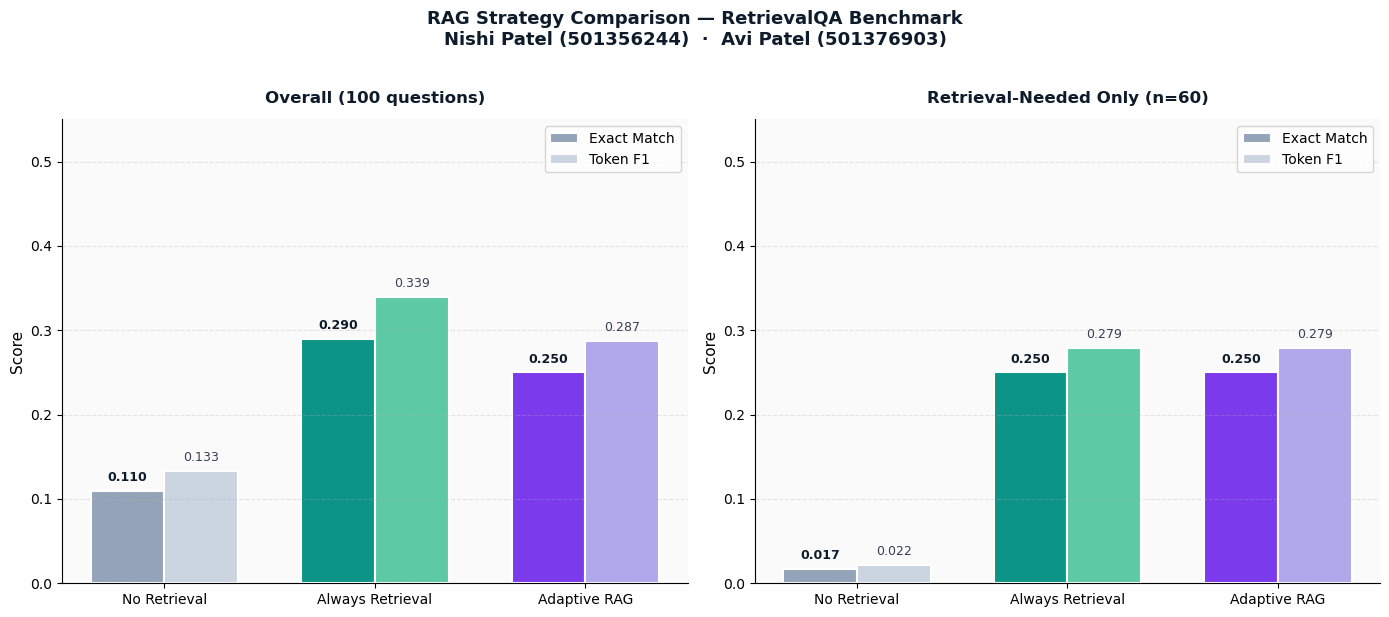

Results chart saved as results_chart.png


In [ ]:
# Generate results bar chart (saved as results_chart.png)
# Full implementation: src/visualisation.py -> plot_results()
plot_results(results_df, save_path='results_chart.png')

In [ ]:
# Error analysis — examine where RAG helped and where it failed
# Full implementation: src/evaluation.py -> error_analysis()
error_analysis(results_df)

ERROR ANALYSIS — 5 Selected Examples

[CASE 1] RAG HELPED — No Retrieval wrong, Always RAG correct
------------------------------------------------------------
Question     : What is the minimum annual income required for a family of four to be considered middle class in Delaware in 2023, according to the study?
Gold answer  : ['$67,830']
No Retrieval : '$ 750'  WRONG
Always RAG   : '$67,830'  CORRECT
Data source  : realtimeqa

Question     : What was the stage name of the British comedian Chaim Reuben Weintrop?
Gold answer  : ['Bud Flannagan', 'bud flanagan', 'Bud Flanagan', 'bud flannagan']
No Retrieval : 'chaim reuben'  WRONG
Always RAG   : 'Bud Flanagan'  CORRECT
Data source  : triviaqa

Question     : What is Bolsheustyikinskoye the capital of?
Gold answer  : ['Mechetlinsky District']
No Retrieval : 'russia'  WRONG
Always RAG   : 'Mechetlinsky District'  CORRECT
Data source  : popqa


[CASE 2] RAG FAILED — Both strategies wrong
(Retriever failure or context does not contain the an

## 5. Conclusion and Future Directions

### Results Summary

| Strategy | Exact Match | Token F1 |
|----------|-------------|----------|
| No Retrieval | 0.110 | 0.133 |
| Always Retrieval | 0.290 | 0.339 |
| Adaptive RAG | 0.250 | 0.287 |

The most compelling result is on **retrieval-needed questions (n=60)**:
No Retrieval scored only 0.017 EM — the LLM answered correctly on
barely 1 out of 60 questions from memory alone. Always Retrieval
improved this to 0.250 — a **14× improvement** — simply by providing
retrieved context before generation. This directly confirms the
RetrievalQA paper's core finding.

### Limitations
1. **Small LLM** — flan-t5-base made errors even when the answer was
   clearly present in context. A larger model would perform much better.
2. **Small sample** — 100 questions due to CPU runtime constraints.
3. **Simplified Adaptive** — used oracle label rather than real LLM
   decision-making (TAARE prompting).
4. **Retriever failures** — some passages contained the wrong entity
   (e.g., wrong Dobra River), directly causing incorrect answers.

### Future Directions
1. Replace flan-t5-base with GPT-3.5 or LLaMA-3 for better generation.
2. Implement real TAARE adaptive prompting from the paper.
3. Test on a domain-specific corpus (medical, legal).
4. Use a live Wikipedia retriever to eliminate retriever failures.

## 6. References

[1] Zhang, Z., Fang, M., & Chen, L. (2024). RetrievalQA: Assessing
Adaptive Retrieval-Augmented Generation for Short-form Open-Domain
Question Answering. *ACL Findings 2024*.
https://arxiv.org/abs/2402.16457

[2] Lewis, P., et al. (2020). Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks. *NeurIPS 2020*.

[3] Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence
Embeddings using Siamese BERT-Networks. *EMNLP 2019*.
https://www.sbert.net

[4] Johnson, J., Douze, M., & Jégou, H. (2019). Billion-scale
similarity search with GPUs. *IEEE Transactions on Big Data*.
https://github.com/facebookresearch/faiss

[5] Raffel, C., et al. (2020). Exploring the Limits of Transfer
Learning with a Unified Text-to-Text Transformer. *JMLR*.
(google/flan-t5-base)

[6] Wolf, T., et al. (2020). HuggingFace Transformers:
State-of-the-Art Natural Language Processing. *EMNLP 2020*.
https://huggingface.co/docs/transformers